## Load and Preprocess Data
`emg.csv: timestamp, emg_channel_1, emg_channel_2, emg_channel_3, emg_channel_4, emg_channel_5, emg_channel_6, emg_channel_7, emg_channel_8`

`finger_angles.csv: timestamp, THUMB, INDEX, MIDDLE, RING, PINKY`

In [1]:
import os
import pandas as pd
import re
import json
from exg.ema import EMA
from exg.sma import SMA
from exg.iir import IIR

In [2]:
def load_data(session_dir: str,
              finger_columns: list[str],
              window_sizes: list[int],
              exg_fs: int):
    """
    Load & process one session directory containing:
      - exg.csv      (timestamp + raw EMG channels)
      - prompt.csv   (timestamp + finger columns)
    """
    # Read CSVs
    exg_path    = os.path.join(session_dir, "exg.csv")
    prompt_path = os.path.join(session_dir, "prompt.csv")
    exg_data    = pd.read_csv(exg_path)
    angle_data  = pd.read_csv(prompt_path)

    # Infer column sets
    raw_columns    = [c for c in exg_data.columns   if c != "timestamp"]
    # only pick the finger columns you care about:
    angle_columns  = [c for c in finger_columns    if c in angle_data.columns]

    # Timestamps to timedelta
    exg_data['timestamp']   = pd.to_timedelta(exg_data["timestamp"], unit='ms')
    angle_data['timestamp'] = pd.to_timedelta(angle_data["timestamp"], unit='ms')

    # Apply filters
    iir_params = {
        "num_channels": len(raw_columns),
        "fs": exg_fs,
        "lowpass_fs": exg_fs/2,
        "highpass_fs": 20,
        "notch_fs_list": [50, 60],
        "filter_order": 4
    }
    iir_proc = IIR(
        num_channels=iir_params["num_channels"],
        fs=iir_params["fs"],
        lowpass_fs=iir_params["lowpass_fs"],
        highpass_fs=iir_params["highpass_fs"],
        notch_fs_list=iir_params["notch_fs_list"],
        filter_order=iir_params["filter_order"],
    )
    filtered = iir_proc.process(exg_data[raw_columns].values)
    exg_data[raw_columns] = filtered

    # Apply smoothing methods
    ema_proc = EMA(window_sizes=window_sizes,
                   num_channels=len(raw_columns),
                   fs=exg_fs)
    sma_proc = SMA(window_sizes=window_sizes,
                   num_channels=len(raw_columns),
                   fs=exg_fs)

    ema_vals = ema_proc.process(filtered)
    ema_df   = ema_proc.results_to_df(ema_vals)

    sma_vals = sma_proc.process(filtered)
    sma_df   = sma_proc.results_to_df(sma_vals)

    # Add all columns to exg_data
    processed_exg = pd.concat([exg_data, ema_df, sma_df], axis=1)

    # Shift timestamps to allow user to transition after the prompt
    transition_ms = 0
    # angle_data['timestamp'] += pd.Timedelta(milliseconds=transition_ms)
    tolerance_ms = 5000 - transition_ms

    merged = pd.merge_asof(
        processed_exg.sort_values('timestamp'),
        angle_data[angle_columns + ["timestamp"]].sort_values('timestamp'),
        on="timestamp",
        direction='backward',
        tolerance=pd.Timedelta(milliseconds=tolerance_ms)
    ).set_index("timestamp")
    merged = merged.dropna()

    return merged, raw_columns, ema_df.columns.tolist(), sma_df.columns.tolist(), iir_params


def load_session(session_folder: str,
                 finger_columns: list[str],
                 window_sizes: list[int]):
    """
    Discover all r_<n> subfolders in session_folder, load & process each.
    Returns:
      - sessions: list of DataFrames
      - ema_columns, sma_columns
    """
    # Check if session_folder exists
    if not os.path.exists(session_folder):
        raise FileNotFoundError(f"Session folder {session_folder} does not exist.")
    
    # Check if frequency_info.json exists
    freq_info_path = os.path.join(session_folder, "frequency_info.json")
    if not os.path.exists(freq_info_path):
        raise FileNotFoundError(f"frequency_info.json not found in {session_folder}.")
    
    with open(freq_info_path, 'r') as f:
        freq_info = json.load(f)
    exg_fs = freq_info.get("exg_fs")
    if exg_fs is None:
        raise ValueError("exg_fs not found in frequency_info.json.")
    
    # find all r_<n> dirs
    dirs = [
        d for d in os.listdir(session_folder)
        if os.path.isdir(os.path.join(session_folder, d))
           and re.match(r"^r_(\d+)$", d)
    ]
    # sort by the numeric idx
    dirs.sort(key=lambda d: int(d.split("_", 1)[1]))

    sessions = []
    ema_cols = sma_cols = iir_params = None
    
    for d in dirs:
        full_path = os.path.join(session_folder, d)
        print(f"Loading session {d} …")
                 
        # Load & process the data
        df, raw_cols, ema_cols, sma_cols, iir_params = load_data(
            session_dir    = full_path,
            finger_columns = finger_columns,
            window_sizes   = window_sizes,
            exg_fs         = exg_fs
        )
        sessions.append(df)

    return sessions, exg_fs, raw_cols, ema_cols, sma_cols, iir_params

# Set parameters
window_sizes   = [128]
finger_columns = ["thumb", "index", "middle", "pinky"]
session_folder = "../data/s_04_26_25"    # contains r_0/, r_1/, …

sessions, exg_fs, exg_cols, ema_cols, sma_cols, iir_params = load_session(
    session_folder,
    finger_columns,
    window_sizes,
)

# sessions is now a list of one DataFrame per r_<n> folder
for i, df in enumerate(sessions):
    print(f"Session {i}: {df.shape[0]} rows, columns = {list(df.columns)}")

Loading session r_0 …
Loading session r_1 …
Loading session r_2 …
Session 0: 87561 rows, columns = ['exg_1', 'exg_2', 'exg_3', 'exg_4', 'exg_5', 'exg_6', 'exg_7', 'exg_8', 'exg_9', 'exg_10', 'exg_11', 'exg_12', 'exg_13', 'exg_14', 'exg_15', 'exg_16', 'ch_1_ema_mean_1024ms', 'ch_2_ema_mean_1024ms', 'ch_3_ema_mean_1024ms', 'ch_4_ema_mean_1024ms', 'ch_5_ema_mean_1024ms', 'ch_6_ema_mean_1024ms', 'ch_7_ema_mean_1024ms', 'ch_8_ema_mean_1024ms', 'ch_9_ema_mean_1024ms', 'ch_10_ema_mean_1024ms', 'ch_11_ema_mean_1024ms', 'ch_12_ema_mean_1024ms', 'ch_13_ema_mean_1024ms', 'ch_14_ema_mean_1024ms', 'ch_15_ema_mean_1024ms', 'ch_16_ema_mean_1024ms', 'ch_1_ema_mean_square_1024ms', 'ch_2_ema_mean_square_1024ms', 'ch_3_ema_mean_square_1024ms', 'ch_4_ema_mean_square_1024ms', 'ch_5_ema_mean_square_1024ms', 'ch_6_ema_mean_square_1024ms', 'ch_7_ema_mean_square_1024ms', 'ch_8_ema_mean_square_1024ms', 'ch_9_ema_mean_square_1024ms', 'ch_10_ema_mean_square_1024ms', 'ch_11_ema_mean_square_1024ms', 'ch_12_ema_mean

In [4]:
# Print the Average Value and Standard Deviation for the first data session
def print_stats(data):
    """Prints the average and standard deviation of the data."""
    for column in data.columns:
        print(f"{column}: (MEAN: {data[column].mean()}, STD: {data[column].std()})")
        
print_stats(sessions[0])

exg_1: (MEAN: 0.0005776763714612453, STD: 19.506766451892204)
exg_2: (MEAN: -0.0003047276141845495, STD: 12.11923212301251)
exg_3: (MEAN: -2.0181362124864558e-05, STD: 5.317925764143726)
exg_4: (MEAN: -0.00045039967146320923, STD: 7.869761747529132)
exg_5: (MEAN: -0.0015088674617143138, STD: 10.535812844683997)
exg_6: (MEAN: -0.0019490173624399584, STD: 15.269148458723455)
exg_7: (MEAN: -0.0007162215560649586, STD: 22.651205838326426)
exg_8: (MEAN: -0.00018936780324694838, STD: 8.692470167504771)
exg_9: (MEAN: 0.0002921509716922699, STD: 25.937539690469322)
exg_10: (MEAN: 0.000814095476842279, STD: 24.568877234063283)
exg_11: (MEAN: -0.0002081798061607062, STD: 14.370698193475889)
exg_12: (MEAN: 0.000579575356216952, STD: 22.54912701540322)
exg_13: (MEAN: -0.00040736518281439017, STD: 14.054647423714558)
exg_14: (MEAN: -0.0009784600764160855, STD: 13.135230266691051)
exg_15: (MEAN: -0.000363584472269195, STD: 14.245182587587491)
exg_16: (MEAN: -0.0002593218075104438, STD: 10.2839124729

### Graphing

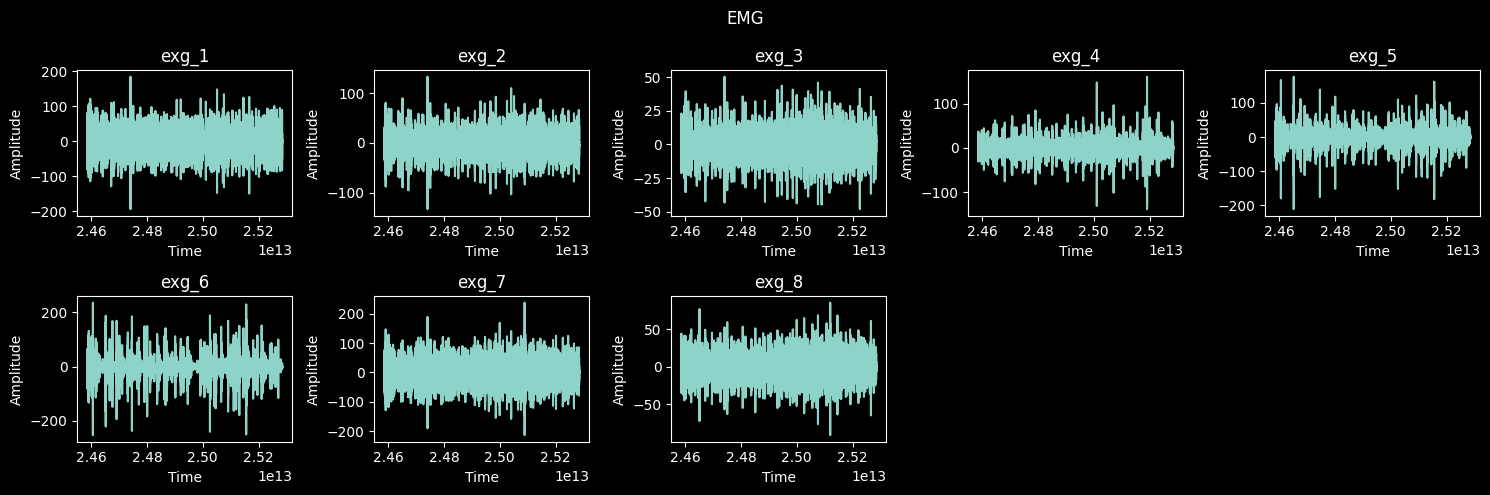

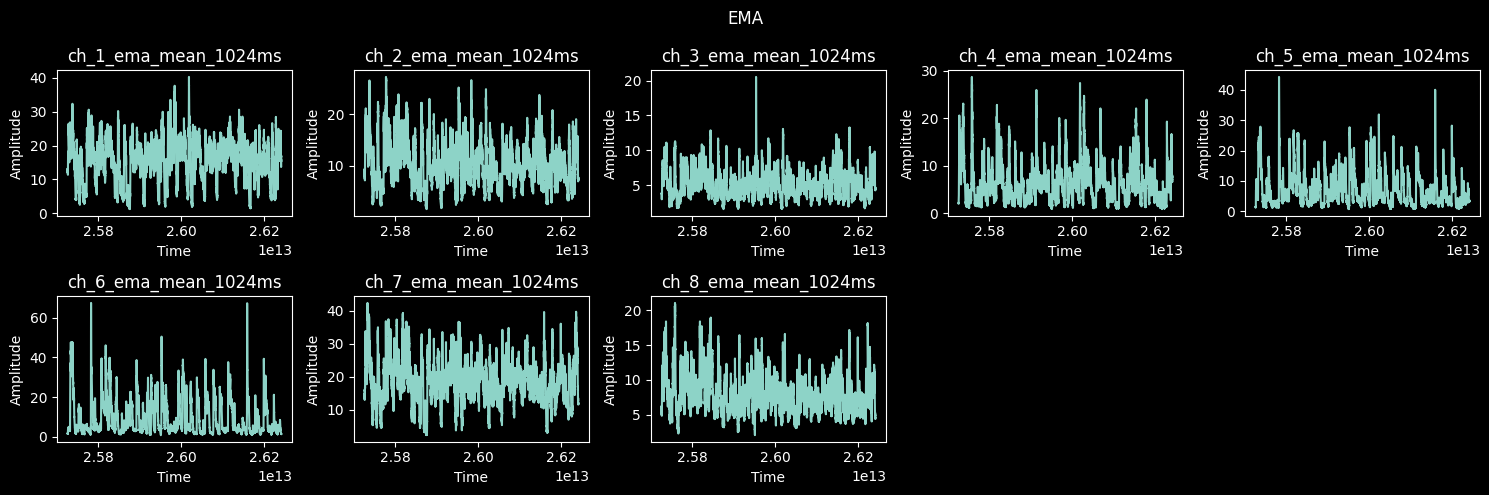

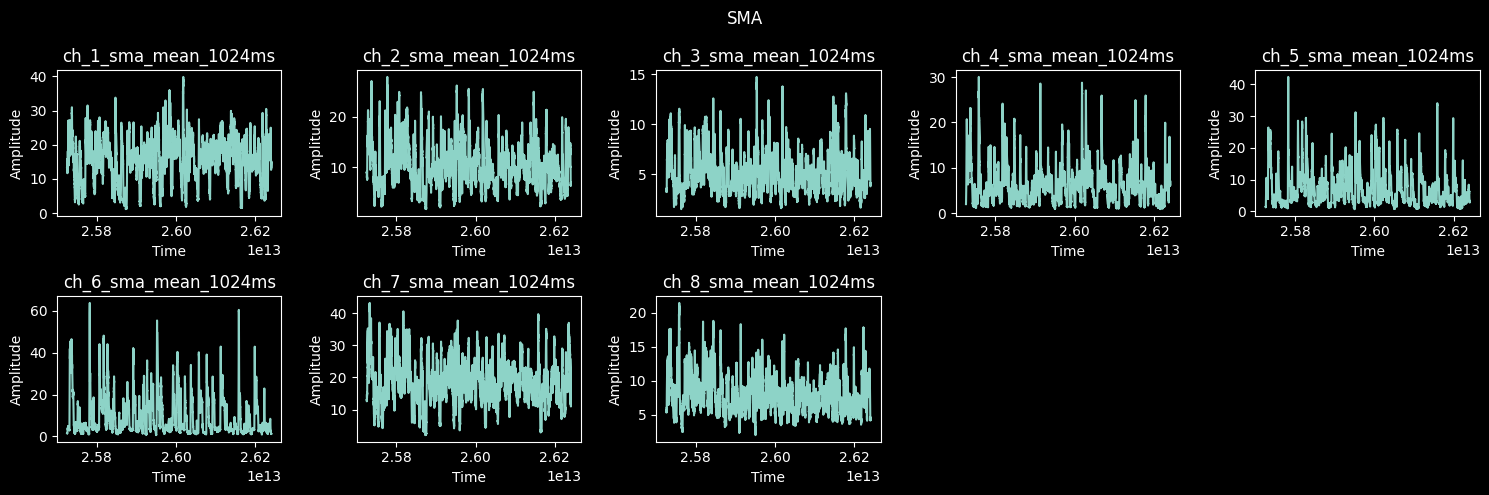

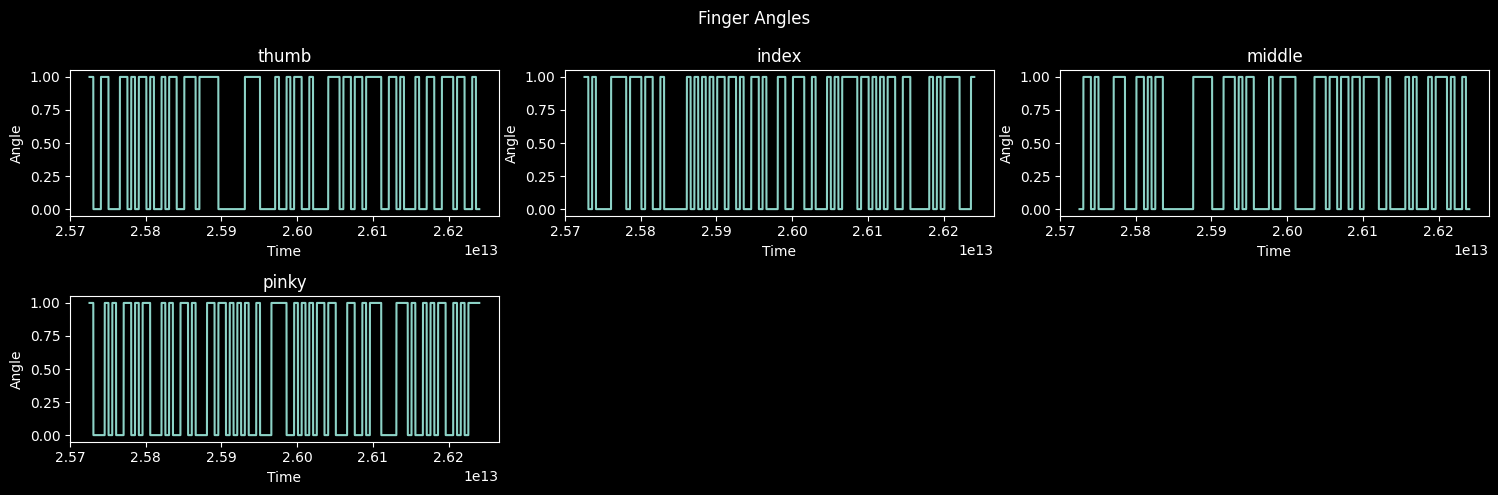

In [5]:
import matplotlib.pyplot as plt

def graph_emg_channel(emg_channel, title="EMG Channel"):
    """Graphs a single EMG channel."""
    plt.figure(figsize=(15, 5))
    plt.plot(emg_channel.abs())
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()
    
def graph_emg(emg_data, emg_columns=None, title="EMG"):
    """Graphs the EMG data for all channels in a 2x4 grid."""
    # If no columns are specified, use all columns except the timestamp
    if emg_columns is None:
        emg_columns = emg_data.columns
    
    # Plot a 2 x 4 grid of EMG data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, channel_name in enumerate(emg_columns):
        plt.subplot(2, 5, i + 1)
        plt.plot(emg_data[channel_name], label=f"{channel_name}")
        plt.title(f"{channel_name}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def graph_finger(finger_data, finger_channels=None, title="Finger Angles"):
    """Graphs the finger angle data for all fingers in a 2x3 grid."""
    # If no columns are specified, use all columns except the timestamp
    if finger_channels is None:
        finger_channels = finger_data.columns
    
    # Plot a 2 x 3 grid of finger data
    plt.figure(figsize=(15, 5))
    plt.suptitle(title)
    for i, finger_name in enumerate(finger_channels):
        plt.subplot(2, 3, i + 1)
        plt.plot(finger_data[finger_name], label=f"{finger_name}")
        plt.title(f"{finger_name}")
        plt.xlabel("Time")
        plt.ylabel("Angle")
    plt.tight_layout()
    plt.show()

# Graph the first subsession
graph_emg(sessions[0][exg_cols[:8]], title="EMG")
graph_emg(sessions[-1][ema_cols[:8]], title="EMA")
graph_emg(sessions[-1][sma_cols[:8]], title="SMA")
graph_finger(sessions[-1][finger_columns], title="Finger Angles")

In [6]:
def drop_nan_sessions(session):
    """Drops NaN values from all data in a session."""
    return [data.dropna() for data in session]

# Drop NaN values from the session
preprocessed = drop_nan_sessions(sessions)
# Print the number of samples before and after dropping NaN values
for i, data in enumerate(sessions):
    print(f"Samples before dropping NaN for session {i}: {len(data)}")
    print(f"Samples after dropping NaN for session {i}: {len(preprocessed[i])}")

Samples before dropping NaN for session 0: 87561
Samples after dropping NaN for session 0: 87561
Samples before dropping NaN for session 1: 26359
Samples after dropping NaN for session 1: 26359
Samples before dropping NaN for session 2: 64354
Samples after dropping NaN for session 2: 64354


## Train/Validation/Test Splits

In [7]:
import numpy as np

# Split the data into training, validation, and test sets
x_cols = [ema_cols[i] for i in range(0, 15)]
finger_columns = ["thumb", "index", "middle", "pinky"] 
num_sessions = len(preprocessed)
preprocessed_range = list(range(0, num_sessions))
val_sessions = preprocessed_range[-1:]
# Set to the difference of the preprocessed range and the validation sessions
train_sessions = list(set(preprocessed_range) - set(val_sessions))

delay = 4 # Delay in frames

X_train = []
y_train = []
for session_idx in train_sessions:
    emg = preprocessed[session_idx][x_cols]
    finger = preprocessed[session_idx][finger_columns]
    X_train.append(emg[:emg.shape[0]-delay])
    y_train.append(finger[delay:])

X_val = []
y_val = []
for session_idx in val_sessions:
    emg = preprocessed[session_idx][x_cols]
    finger = preprocessed[session_idx][finger_columns]
    X_val.append(emg[:emg.shape[0]-delay])
    y_val.append(finger[delay:])
    
X_val_no_delay = []
y_val_no_delay = []
for session_idx in val_sessions:
    emg = preprocessed[session_idx][x_cols]
    finger = preprocessed[session_idx][finger_columns]
    X_val_no_delay.append(emg)
    y_val_no_delay.append(finger)
    
# Combine the training and validation sets
X_train = np.concatenate(X_train)
X_val = np.concatenate(X_val)
y_train = np.concatenate(y_train)
y_val = np.concatenate(y_val)
X_val_no_delay = np.concatenate(X_val_no_delay)
y_val_no_delay = np.concatenate(y_val_no_delay)

# Mean and standard deviation for each channel
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Normalize the data
# train_mean = 0 # If you want to keep every signal above 0
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_val_no_delay = (X_val_no_delay - train_mean) / train_std

# Print the shapes of the training and validation sets
print(f"X_train shape: {X_train.shape}, Y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, Y_val shape: {y_val.shape}")

X_train shape: (113912, 15), Y_train shape: (113912, 4)
X_val shape: (64350, 15), Y_val shape: (64350, 4)


### MLP Model

## 🔁 Spiking Neural Network (snnTorch) — Temporal Dependence

In [8]:
# Imports for SNN
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import snntorch as snn
from snntorch import surrogate
import numpy as np

from sklearn.metrics import r2_score

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("SNN Device:", DEVICE)

SNN Device: mps


In [9]:
# Sequence dataset based on already-prepared arrays: X_train, y_train, X_val, y_val
class SeqDataset(Dataset):
    def __init__(self, X, Y, seq_len):
        assert len(X) == len(Y), "X/Y length mismatch"
        self.X = X.astype(np.float32)
        self.Y = Y.astype(np.float32)
        self.T = seq_len
        self.N = len(X) - seq_len + 1
        if self.N < 1:
            raise ValueError("Sequence length is longer than the available stream.")
    def __len__(self):
        return self.N
    def __getitem__(self, idx):
        x = self.X[idx:idx+self.T]
        y = self.Y[idx:idx+self.T]
        return torch.from_numpy(x), torch.from_numpy(y)

# Adjust to your stream rate/latency tradeoff
SEQ_LEN  = 50   # ~200 ms @ 250 Hz
BATCH_SZ = 256

in_dim  = X_train.shape[1]
out_dim = y_train.shape[1]

train_ds = SeqDataset(X_train, y_train, SEQ_LEN)
val_ds   = SeqDataset(X_val,   y_val,   SEQ_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SZ, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SZ, shuffle=False, drop_last=False)

in_dim, out_dim

(15, 4)

In [ ]:
# Recurrent Leaky-Integrate-and-Fire (R-LIF) spiking model
class SpikingTemporalNet(nn.Module):
    def __init__(self, in_dim: int, hidden: int, out_dim: int,
                 beta: float = 0.9, threshold: float = 1.0):
        super().__init__()
        self.fc_in  = nn.Linear(in_dim, hidden)
        self.rlif   = snn.RLeaky(beta=beta, threshold=threshold)
        self.fc_out = nn.Linear(hidden, out_dim)

    def forward(self, x):
        # x: (B, T, C)
        B, T, C = x.shape
        mem = torch.zeros(B, self.fc_in.out_features, device=x.device)
        h   = torch.zeros_like(mem)
        logits_seq = []
        for t in range(T):
            cur = self.fc_in(x[:, t, :])
            spk, mem, h = self.rlif(cur, mem, h)
            logits_seq.append(self.fc_out(spk))
        return torch.stack(logits_seq, dim=1)  # (B, T, D)

model = SpikingTemporalNet(in_dim, hidden=128, out_dim=out_dim).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
model

TypeError: RLeaky.__init__() got an unexpected keyword argument 'surrogate_function'

In [ ]:
# Evaluation: compute macro R^2 over flattened timeline
@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    all_logits = []
    all_targets = []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb).cpu().numpy()  # (B,T,D)
        all_logits.append(logits)
        all_targets.append(yb.numpy())
    L = np.concatenate(all_logits, axis=0).reshape(-1, out_dim)  # (N* T, D)
    Y = np.concatenate(all_targets, axis=0).reshape(-1, out_dim)
    P = 1.0 / (1.0 + np.exp(-L))
    r2s = []
    for i in range(out_dim):
        try:
            r2s.append(max(r2_score(Y[:, i], P[:, i]), 0))
        except ValueError:
            r2s.append(0.0)
    return float(np.mean(r2s))

In [ ]:
# Training loop with early stopping on R^2
from math import isfinite

def train(model, train_dl, val_dl, epochs=100, patience=10):
    best, wait = -1e9, 0
    best_state = None
    for ep in range(1, epochs+1):
        model.train()
        tot, n = 0.0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += float(loss.item()); n += 1
        val_r2 = eval_epoch(model, val_dl)
        print(f"Epoch {ep:03d} | loss={tot/max(n,1):.4f} | val R2={val_r2:.4f}")
        if val_r2 > best + 1e-4:
            best = val_r2
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break
    if best_state is not None:
        model.load_state_dict(best_state)

train(model, train_dl, val_dl, epochs=100, patience=10)

In [ ]:
# Save model + parameters in a simple, compatible format
import json, os

def save_snn(model_dir="./models/snn_model_0"):
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(model_dir, "model.pt"))
    params = {
        "seq_len": SEQ_LEN,
        "in_dim": in_dim,
        "out_dim": out_dim,
        "hidden": 128,
        "beta": 0.9,
        "threshold": 1.0,
    }
    with open(os.path.join(model_dir, "model_params.json"), "w") as f:
        json.dump(params, f, indent=2)

save_snn()
print("Saved SNN model and params.")

> **Replaced:** This cell previously contained Keras MLP/CNN logic. It has been superseded by the SNN implementation below.

> **Replaced:** This cell previously contained Keras MLP/CNN logic. It has been superseded by the SNN implementation below.

In [113]:
from math import sqrt
from sklearn.metrics import r2_score

# Evaluate on the validation set
val_loss, val_r2, val_b_acc = model.evaluate(X_val, y_val, verbose=0)
y_pred = model.predict(X_val)

print(f"Validation Loss: {val_loss}")
if val_r2 > 0:
    print(f"Validation R Score: {sqrt(val_r2)}")
print(f"Validation R2 Score: {val_r2}")
print(f"Validation Binary Accuracy: {val_b_acc}")
# Calculate and print the correlation coefficient for each finger
for i, finger in enumerate(finger_columns):
    r2 = r2_score(y_val[:, i], y_pred[:, i])
    if r2 < 0:
        r2 = 0
    print(f"R score for {finger}: {sqrt(r2)}")

2011/2011 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step
Validation Loss: 0.4166424870491028
Validation R Score: 0.7054604209839122
Validation R2 Score: 0.4976744055747986
Validation Binary Accuracy: 0.8379331827163696
R score for thumb: 0.6424467553026016
R score for index: 0.6644106310837502
R score for middle: 0.7643638239382174
R score for pinky: 0.7431455518436767


#### Save model

In [112]:
def extract_method_interval_xcols(xma:str="ema"):
    """Extracts the channel name from the column name."""
    xma_methods = set()
    xma_intervals = set()
    for col in x_cols:
        if xma in col:
            split = col.split("_")
            method = split[3:-1]
            method = "_".join(method)
            interval = int(split[-1][:-2])
            
            xma_methods.add(method)
            xma_intervals.add(interval)
    xma_methods = sorted(list(xma_methods))
    xma_intervals = sorted(list(xma_intervals))

    return xma_methods, xma_intervals

In [18]:
def save_model():
    model_dir = session_folder + "/models/model_0"

    # Create the models directory if it does not exist
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)
    model.save(f"{model_dir}/model.keras")

    # Extract the methods and intervals for EMA and SMA
    ema_methods, ema_intervals = extract_method_interval_xcols(xma="ema")
    sma_methods, sma_intervals = extract_method_interval_xcols(xma="sma")
    # Save the model parameters to a JSON file
    model_params = {
        "finger_cols": finger_columns,
        "x_cols": x_cols,
        "exg_fs": exg_fs,
        "ema_methods": ema_methods,
        "ema_intervals": ema_intervals,
        "sma_methods": sma_methods,
        "sma_intervals": sma_intervals,
        "mean": train_mean.tolist(),
        "std": train_std.tolist(),
        "iir_params": iir_params,
    }
    with open(f"{model_dir}/model_params.json", 'w') as f:
        json.dump(model_params, f, indent=4)

# Save the model
save_model()

### Determine which are the best 8 (or n) Channels
Takes very long to run, only run if you want to determine the most important n important channels, such as to reduce the number of channels.

In [14]:
%pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


> **Replaced:** This cell previously contained Keras MLP/CNN logic. It has been superseded by the SNN implementation below.

### Visualize Model Results on Validation Data

In [8]:
import pandas as pd

y_pred = (model.predict(X_val_no_delay) > 0.5) * 1
y_test_df = pd.DataFrame(y_val_no_delay, columns=finger_columns)
y_pred_df = pd.DataFrame(y_pred, columns=finger_columns)

NameError: name 'model' is not defined

In [9]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import display
import plotly.io as pio

def create_plotly_animation(
    y_true, 
    y_pred, 
    finger_names, 
    window_size=250*5, 
    step_size=10, 
    fps=10, 
    max_fingers=5,
    external_window=False
):
    """
    Creates an efficient animated Plotly figure with multiple subplots, each representing a finger.
    
    Parameters:
    - y_true: pandas DataFrame containing actual target values.
    - y_pred: pandas DataFrame containing predicted target values.
    - finger_names: List of finger names (columns in DataFrame).
    - window_size: Number of samples to display per frame.
    - step_size: Number of samples to move forward in each frame.
    - fps: Frames per second for the animation.
    - max_fingers: Maximum number of fingers (subplots) to plot simultaneously.
    - external_window: If True, opens the animation in a separate browser window.
    
    Returns:
    - Plotly Figure object.
    """
    # Limit the number of fingers to plot for efficiency
    if len(finger_names) > max_fingers:
        print(f"Limiting to first {max_fingers} fingers for performance.")
        finger_names = finger_names[:max_fingers]
        y_true = y_true[finger_names]
        y_pred = y_pred[finger_names]
    
    num_fingers = len(finger_names)
    num_samples = len(y_true)
    
    # Calculate the number of frames
    frames_indices = list(range(0, num_samples - window_size + step_size, step_size))
    if not frames_indices:
        frames_indices = [0]
    
    # Create subplots: one row per finger
    fig = make_subplots(
        rows=num_fingers, 
        cols=1, 
        shared_xaxes=True,
        subplot_titles=finger_names,
        vertical_spacing=0.05
    )
    
    # Initialize traces for each finger
    for i, finger in enumerate(finger_names, start=1):
        # Actual values
        fig.add_trace(
            go.Scatter(
                x=[], 
                y=[],
                mode='lines',
                line=dict(color='blue'),
                name=f'{finger} - Actual',
                showlegend=(i == 1)  # Show legend only for the first subplot
            ),
            row=i, 
            col=1
        )
        # Predicted values
        fig.add_trace(
            go.Scatter(
                x=[], 
                y=[],
                mode='lines',
                line=dict(color='red', dash='dash'),
                name=f'{finger} - Predicted',
                showlegend=(i == 1)  # Show legend only for the first subplot
            ),
            row=i, 
            col=1
        )
        
        # Fix the y-axis range between 0 and 1
        fig.update_yaxes(range=[-0.05, 1.05], row=i, col=1)
    
    # Generate frames
    frames = []
    for start in frames_indices:
        end = start + window_size
        if end > num_samples:
            end = num_samples
            start = max(end - window_size, 0)
        frame_data = []
        x_range = list(range(end - start))
        for i, finger in enumerate(finger_names):
            # Actual data
            actual = y_true.iloc[start:end, i].values
            # Predicted data
            pred = y_pred.iloc[start:end, i].values
            # Append updated traces
            frame_data.append(go.Scatter(x=x_range, y=actual))
            frame_data.append(go.Scatter(x=x_range, y=pred))
        frames.append(go.Frame(data=frame_data, name=str(start)))
    
    fig.frames = frames
    
    # Add play and pause buttons
    fig.update_layout(
        updatemenus=[
            dict(
                type='buttons',
                showactive=False,
                y=1,
                x=1.05,
                xanchor='right',
                yanchor='top',
                pad=dict(t=0, r=10),
                buttons=[
                    dict(
                        label='Play',
                        method='animate',
                        args=[
                            None,
                            dict(
                                frame=dict(duration=1000/fps, redraw=True),
                                transition=dict(duration=0),
                                fromcurrent=True,
                                mode='immediate'
                            )
                        ]
                    ),
                    dict(
                        label='Pause',
                        method='animate',
                        args=[
                            [None],
                            dict(
                                frame=dict(duration=0, redraw=False),
                                transition=dict(duration=0),
                                mode='immediate'
                            )
                        ]
                    )
                ]
            )
        ],
        sliders=[
            dict(
                active=0,
                currentvalue=dict(prefix='Start Index: '),
                pad=dict(t=50, b=10),
                steps=[
                    dict(
                        method='animate',
                        args=[
                            [str(start)],
                            dict(
                                frame=dict(duration=1000/fps, redraw=True),
                                transition=dict(duration=0),
                                mode='immediate'
                            )
                        ],
                        label=str(start)
                    ) for start in frames_indices
                ]
            )
        ],
        height=300*num_fingers, 
        width=900, 
        showlegend=True,
        title='Real-Time Animation of Predictions vs Actual Values'
    )
    
    # Set initial data
    if frames:
        initial_start = frames_indices[0]
        initial_end = initial_start + window_size
        if initial_end > num_samples:
            initial_end = num_samples
            initial_start = max(initial_end - window_size, 0)
        x_initial = list(range(initial_end - initial_start))
        for i, finger in enumerate(finger_names):
            actual = y_true.iloc[initial_start:initial_end, i].values
            pred = y_pred.iloc[initial_start:initial_end, i].values
            fig['data'][2*i].x = x_initial
            fig['data'][2*i].y = actual
            fig['data'][2*i+1].x = x_initial
            fig['data'][2*i+1].y = pred
    
    # Display the figure
    if external_window:
        # Use 'browser' renderer to open the animation in a separate browser window
        pio.renderers.default = 'browser'
    else:
        # Use the default renderer (typically inline in Jupyter)
        pio.renderers.default = 'notebook'
    
    return fig


# Define parameters
window_size = 100    # Number of samples per frame
step_size = int(250 * 1/10)       # Step size for each frame
fps = 10             # Frames per second
max_fingers = 5      # Adjust based on your system's capability

# Create the Plotly animation
plotly_fig = create_plotly_animation(
    y_true=y_test_df, 
    y_pred=y_pred_df, 
    finger_names=finger_columns, 
    window_size=window_size, 
    step_size=step_size, 
    fps=fps, 
    max_fingers=max_fingers
)

# Display the figure in Jupyter Notebook
plotly_fig.show()

NameError: name 'y_test_df' is not defined

### MAV, WL, WA, and VAR

In [ ]:
# %%
import pandas as pd
import numpy as np

def compute_MAV(signal_window):
    """Mean of the Absolute Value"""
    return np.mean(np.abs(signal_window))

def compute_WL(signal_window):
    """Waveform Length"""
    return np.sum(np.abs(np.diff(signal_window)))

def compute_WA(signal_window, threshold=0.02):
    """Willison Amplitude (count of threshold crossings)"""
    return np.sum(np.abs(signal_window) > threshold)

def compute_VAR(signal_window):
    """Variance"""
    return np.var(signal_window)

## CNN Model

> **Replaced:** This cell previously contained Keras MLP/CNN logic. It has been superseded by the SNN implementation below.